In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install motmetrics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 14.6 MB/s eta 0:00:00


In [ ]:
import os
if not os.path.exists('ByteTrack'):
    !git clone https://github.com/ifzhang/ByteTrack.git
%cd ByteTrack
# Remove onnx-related requirements to avoid wheel build errors
!sed -i '/onnx/d' requirements.txt
!pip install -q -r requirements.txt
!python3 setup.py -q develop
!pip install -q cython_bbox
%cd ..

Cloning into 'ByteTrack'...
remote: Enumerating objects: 2007, done.
remote: Counting objects: 100% (346/346), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 2007 (delta 304), reused 296 (delta 296), pack-reused 1661 (from 1)
Receiving objects: 100% (2007/2007), 79.59 MiB | 16.44 MiB/s, done.
Resolving deltas: 100% (1160/1160), done.
/content/ByteTrack
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.3 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``s

In [ ]:
import time
import numpy as np
import pickle
import math
from shapely.geometry import Polygon

def box_iou_bev(box1, box2):
    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if not poly1.is_valid or not poly2.is_valid:
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0
    return iou

print("box_iou_bev function updated: debug prints removed.")

box_iou_bev function updated: debug prints removed.


In [ ]:
# 1. Load detection outputs from previous experiment.
# 2. Sort frames in chronological order.
import pickle
# Dummy data generation for demonstration if results.pkl is not present
import os
if not os.path.exists('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl'):
    print("results.pkl not found, creating dummy data for demonstration.")
    dummy_results = []
    for frame_id in range(10):
        dummy_results.append({
            'frame_id': str(frame_id).zfill(6),
            'boxes_lidar': np.array([[10 + frame_id, 2, -1, 4, 2, 1.5, 0], [15, -2 + frame_id, -1, 4, 2, 1.5, 0]]),
            'score': np.array([0.9, 0.85]),
            'name': np.array(['Car', 'Car'])
        })
    with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'wb') as f:
        pickle.dump(dummy_results, f)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    detection_results = pickle.load(f)

# Sort by frame ID
detection_results.sort(key=lambda x: x['frame_id'])

In [ ]:
import sys
import os
if '/content/ByteTrack' not in sys.path:
    sys.path.append('/content/ByteTrack')

import numpy as np
# Compatibility patch for older code using np.float
if not hasattr(np, 'float'):
    np.float = float

# Import the official BYTETracker from the cloned repo
from yolox.tracker.byte_tracker import BYTETracker

# ByteTrack expects an args object for its configuration
class ByteTrackArgs:
    def __init__(self, track_thresh=0.5, track_buffer=30, match_thresh=0.8):
        self.track_thresh = track_thresh
        self.track_buffer = track_buffer
        self.match_thresh = match_thresh
        self.mot20 = False # Not using MOT20 specific logic

print("Official BYTETracker imported successfully!")

Official BYTETracker imported successfully!


In [ ]:
import time
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# 1. Group detections by sequence
sequences_data = {}
class_map = {'Car': 0, 'Pedestrian': 1, 'Cyclist': 2}
inv_class_map = {0: 'Car', 1: 'Pedestrian', 2: 'Cyclist'}

print("Processing raw detections...")
for det in detection_results:
    raw_id_str = str(det['frame_id']).zfill(8)
    seq_id = raw_id_str[:4]
    frame_num = int(raw_id_str[4:])

    if seq_id not in sequences_data:
        sequences_data[seq_id] = []

    boxes = det.get('boxes_lidar', [])
    scores = det.get('score', [])
    names = det.get('name', [])

    dets_formatted = []
    for b, s, n in zip(boxes, scores, names):
        c = class_map.get(n, -1)
        if c != -1:
            dets_formatted.append(np.concatenate([b, [s], [c]]))

    if len(dets_formatted) > 0:
        dets_formatted = np.array(dets_formatted)
    else:
        dets_formatted = np.empty((0, 9))

    sequences_data[seq_id].append({
        'frame_id': raw_id_str,
        'parsed_frame_num': frame_num,
        'dets': dets_formatted
    })

# 2. Run Tracking using OFFICIAL ByteTrack
tracking_results = {}
total_frames = 0
total_time = 0.0

for seq_id, frames in sequences_data.items():
    print(f"Tracking sequence {seq_id} ({len(frames)} frames)...")
    frames.sort(key=lambda x: x['parsed_frame_num'])

    args = ByteTrackArgs(track_thresh=0.75, track_buffer=50, match_thresh=0.8)
    tracker = BYTETracker(args, frame_rate=10)
    tracking_results[seq_id] = {}

    for frame_data in frames:
        start_time = time.time()
        dets = frame_data['dets']

        # Prepare 2D BEV inputs for official ByteTrack: [x1, y1, x2, y2, score]
        dets_2d = np.empty((len(dets), 5))
        if len(dets) > 0:
            # x, y are center points; l, w are dimensions
            dets_2d[:, 0] = dets[:, 0] - dets[:, 3] / 2 # x1
            dets_2d[:, 1] = dets[:, 1] - dets[:, 4] / 2 # y1
            dets_2d[:, 2] = dets[:, 0] + dets[:, 3] / 2 # x2
            dets_2d[:, 3] = dets[:, 1] + dets[:, 4] / 2 # y2
            dets_2d[:, 4] = dets[:, 7] # score

        # ByteTrack requires img_info and img_size, dummy values are fine for pure coordinates
        dummy_info = [1000, 1000]
        if len(dets_2d) > 0:
            online_targets = tracker.update(dets_2d, dummy_info, dummy_info)
        else:
            online_targets = tracker.update(np.empty((0, 5)), dummy_info, dummy_info)

        total_time += time.time() - start_time
        total_frames += 1

        # Match 2D tracked targets back to original 3D detections to retain Z, H, Theta
        frame_tracks = []
        if len(online_targets) > 0 and len(dets) > 0:
            trk_centers = np.array([[t.tlwh[0] + t.tlwh[2]/2, t.tlwh[1] + t.tlwh[3]/2] for t in online_targets])
            det_centers = dets[:, :2]
            # Match using center distance
            dist_matrix = cdist(trk_centers, det_centers)
            row_ind, col_ind = linear_sum_assignment(dist_matrix)

            for r, c in zip(row_ind, col_ind):
                if dist_matrix[r, c] < 2.0: # Match threshold in meters
                    t = online_targets[r]
                    orig_det = dets[c]
                    cls_idx = int(orig_det[8])
                    frame_tracks.append({
                        'track_id': t.track_id,
                        'state': orig_det[:7].copy(), # Restore full 3D state
                        'class_name': inv_class_map.get(cls_idx, 'Car')
                    })

        tracking_results[seq_id][frame_data['frame_id']] = frame_tracks

fps = total_frames / total_time if total_time > 0 else 0
print(f"\nTracking completed! Processed {total_frames} frames.")
print(f"Tracking FPS: {fps:.2f}")

Processing raw detections...
Tracking sequence 0017 (145 frames)...
Tracking sequence 0018 (339 frames)...
Tracking sequence 0019 (1059 frames)...
Tracking sequence 0020 (837 frames)...

Tracking completed! Processed 2380 frames.
Tracking FPS: 839.71


In [ ]:
import motmetrics as mm
import numpy as np
import os

target_classes = ['Car', 'Pedestrian', 'Cyclist']
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}
accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

iou_threshold = 0.1
max_distance = 1.0 - iou_threshold

def load_calib_inv(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line: key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2: key, val = parts[0], parts[1]
            else: continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)
    V2C_raw = np.eye(4)
    if 'Tr_velo_cam' in calib: V2C_raw[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib: V2C_raw[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)
    R0_rect = np.eye(4)
    if 'R_rect' in calib: R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib: R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)
    V2C = R0_rect @ V2C_raw
    return np.linalg.inv(V2C)

gt_data = {}
for seq_id in sequences_data.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
    C2V = load_calib_inv(calib_file) if os.path.exists(calib_file) else np.eye(4)
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                frame, track_id, obj_type = int(parts[0]), int(parts[1]), parts[2]
                if obj_type not in target_classes: continue
                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                pt_cam = np.array([float(parts[13]), float(parts[14]), float(parts[15]), 1.0])
                pt_lidar = C2V @ pt_cam
                state = np.array([pt_lidar[0], pt_lidar[1], pt_lidar[2], l, w, h, -float(parts[16])])
                if frame not in gt_data[seq_id]: gt_data[seq_id][frame] = []
                gt_data[seq_id][frame].append({'track_id': track_id, 'state': state, 'class_name': obj_type})

print("Calculating updated metrics...")
for seq_id, seq_frames in tracking_results.items():
    for raw_frame_id, track_objs in seq_frames.items():
        frame_num = int(str(raw_frame_id)[4:])
        gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
        for cls in target_classes:
            gt_cls = [o for o in gt_objs if o['class_name'] == cls]
            tr_cls = [t for t in track_objs if t['class_name'] == cls]
            dist_matrix = np.zeros((len(gt_cls), len(tr_cls)))
            for i, g in enumerate(gt_cls):
                for j, t in enumerate(tr_cls):
                    d = 1.0 - box_iou_bev(g['state'], t['state'])
                    dist_matrix[i, j] = d if d <= max_distance else np.nan
            accs[cls].update([o['track_id'] for o in gt_cls], [o['track_id'] for o in tr_cls], dist_matrix)
            acc_overall.update([o['track_id'] + class_offsets[cls] for o in gt_cls], [o['track_id'] + class_offsets[cls] for o in tr_cls], dist_matrix)

mh = mm.metrics.create()
print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
display(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    display(cls_summary)


Calculating updated metrics...

Overall Metrics:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
overall,0.739447,0.781692,0.701534,0.77459,0.863095,191,107,73,11,1850,3394,50,475,0.648403,0.601692,6,47,3



Metrics for Car:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Car,0.745453,0.773538,0.719337,0.811648,0.872805,116,70,39,7,920,1465,26,80,0.690023,0.730277,1,26,1



Metrics for Pedestrian:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Pedestrian,0.735618,0.799453,0.681223,0.736827,0.864708,65,30,32,3,792,1808,24,383,0.618049,0.431061,5,21,2



Metrics for Cyclist:


,idf1,idp,idr,recall,precision,num_unique_objects,mostly_tracked,partially_tracked,mostly_lost,num_false_positives,num_misses,num_switches,num_fragmentations,mota,motp,num_transfer,num_ascend,num_migrate
Cyclist,0.68982,0.676056,0.704156,0.704156,0.676056,10,7,2,1,138,121,0,12,0.366748,0.782194,0,0,0


In [ ]:
import os
# Extract the specific metrics from the motmetrics summary DataFrame
# Using 'overall' instead of 'acc' as per our previous update
mota = summary.loc['overall', 'mota']
motp = summary.loc['overall', 'motp']
idsw = summary.loc['overall', 'num_switches']

# The 'fps' variable is already in your workspace from the tracking cell
# Create a dictionary of the results
metrics_summary = {
    'MOTA': mota,
    'MOTP': motp,
    'IDSW': idsw,
    'FPS': fps
}

# Define the save path in your Google Drive
save_dir = '/content/drive/MyDrive/Kitti_tracking/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'tracking_4_params_summary.txt')

# Write the summary to a text file
with open(save_path, 'w') as f:
    f.write("KITTI Tracking Summary (4 Parameters)\n")
    f.write("="*40 + "\n")
    for key, value in metrics_summary.items():
        if isinstance(value, float):
            f.write(f"{key}: {value:.4f}\n")
        else:
            f.write(f"{key}: {value}\n")

print(f"Summary successfully saved to: {save_path}")

# Also display here to confirm
for key, value in metrics_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Summary successfully saved to: /content/drive/MyDrive/Kitti_tracking/tracking_4_params_summary.txt
MOTA: 0.6484
MOTP: 0.6017
IDSW: 50
FPS: 660.6146


Visualisation

In [ ]:
import cv2
import numpy as np

def project_3d_to_2d(state, V2C, P2):
    # Extract state
    x, y, z, l, w, h, theta = state

    # 3D bounding box corners in Lidar coordinate system
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2] # Centered around z

    # Rotation matrix around z-axis in Lidar coordinates
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Rotate and translate corners
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])

    # Transform Lidar to Camera coordinates using V2C
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    # Filter out points behind the camera
    if np.any(corners_cam[:, 2] < 0.1):
        return None

    # Project to 2D image coordinates using P2
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]

    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image

    # Draw edges of the 3D bounding box
    # Bottom face
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[1]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[2]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[3]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[0]), color, 2)

    # Top face
    cv2.line(image, tuple(corners_2d[4]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[5]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[6]), tuple(corners_2d[7]), color, 2)
    cv2.line(image, tuple(corners_2d[7]), tuple(corners_2d[4]), color, 2)

    # Vertical lines connecting top and bottom faces
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[4]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[7]), color, 2)

    # Add label
    label = f"{class_name} {track_id}"
    # Position label near the top left corner of the box
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

print("Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.")

Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.


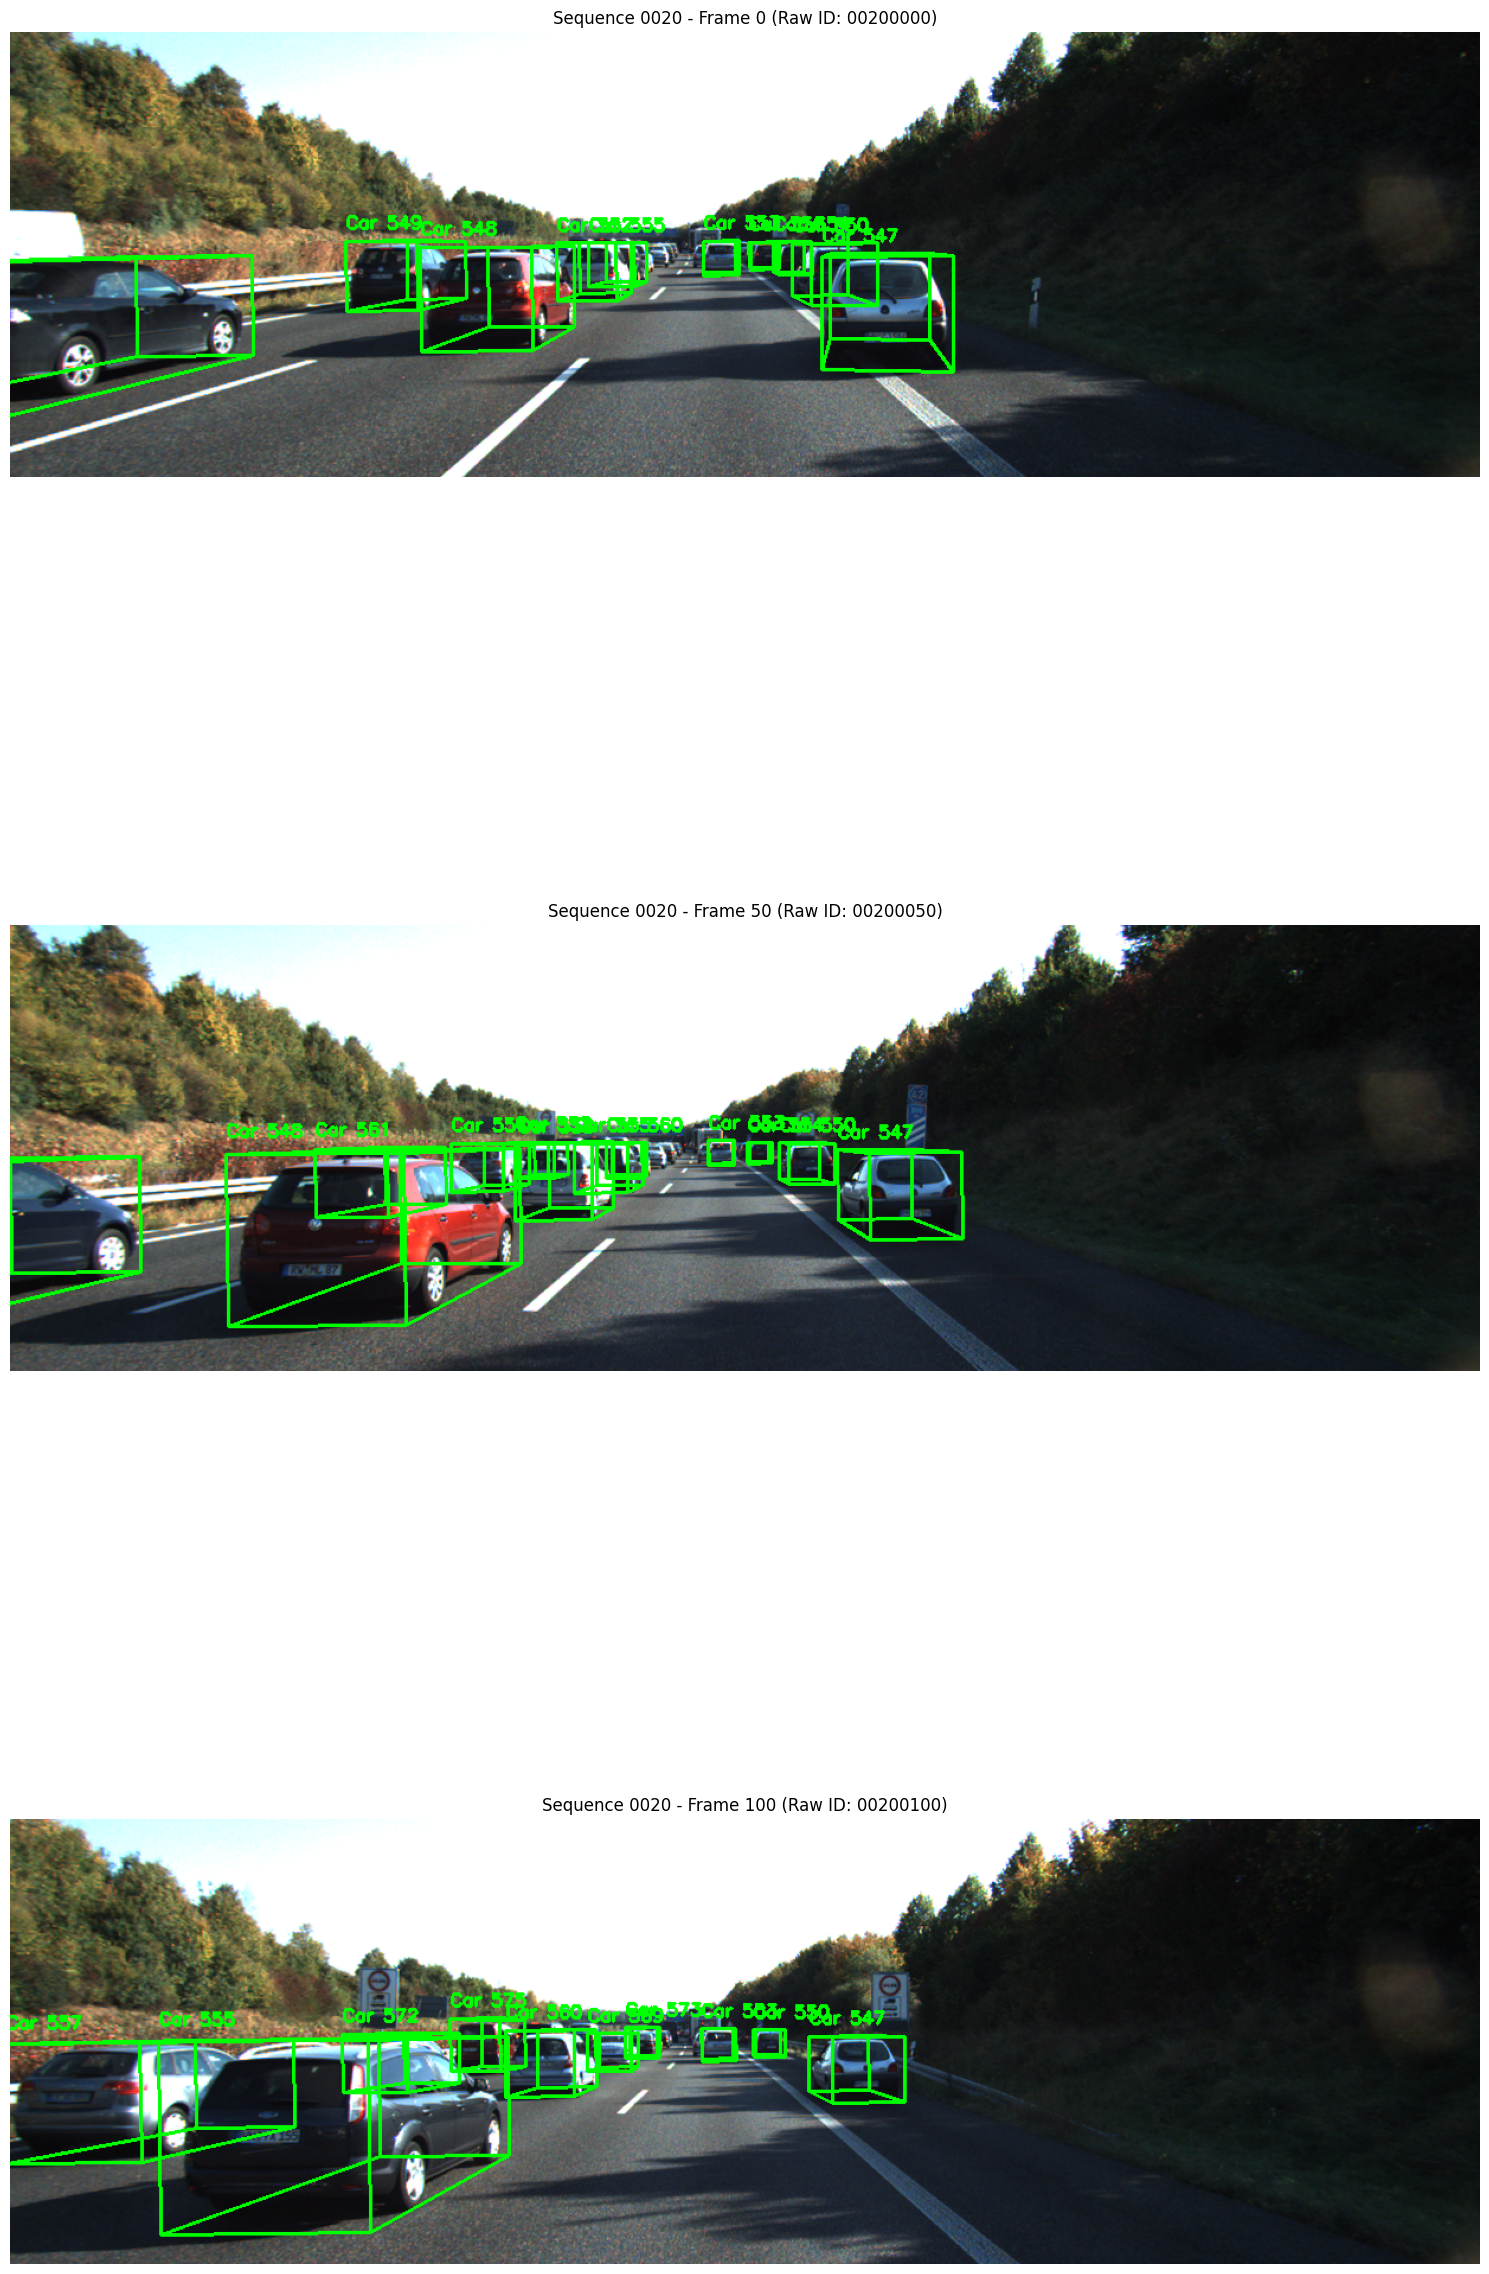

In [ ]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_calib_matrices(filepath):
    """Loads P2 and V2C matrices from a KITTI calibration file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    P2 = calib.get('P2', np.eye(4)[:3, :4]).reshape(3, 4)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    # Matrix to convert Lidar (Velo) to Cam
    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

# Paths to images and calibration
image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

# Select a sequence and some frames
seq_id = '0020'
sample_frames = [0, 50, 100]

calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
if not os.path.exists(calib_file):
    print(f"Warning: Calibration file missing for {seq_id}")
else:
    # Load calibration matrices
    P2, V2C = load_calib_matrices(calib_file)

    # Set up plot
    fig, axes = plt.subplots(len(sample_frames), 1, figsize=(15, 10 * len(sample_frames)))
    if len(sample_frames) == 1:
        axes = [axes]

    for ax, frame_num in zip(axes, sample_frames):
        # 1. Find the correct raw_frame_id from the sequences_data dictionary
        seq_frames = sequences_data.get(seq_id, [])
        matching_frame_data = [f for f in seq_frames if f['parsed_frame_num'] == frame_num]

        if not matching_frame_data:
            print(f"Frame {frame_num} not found in sequence {seq_id} data.")
            continue

        # Take the first match
        frame_data = matching_frame_data[0]
        raw_frame_id = str(frame_data['frame_id'])

        # 2. Get tracking results using the exact raw_frame_id
        frame_tracks = tracking_results.get(seq_id, {}).get(raw_frame_id, [])

        # Format frame number as 6 digits for the image path
        frame_str = str(frame_num).zfill(6)
        image_path = os.path.join(image_dir, seq_id, f"{frame_str}.png")

        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue

        # Load image
        img = cv2.imread(image_path)
        if img is None:
             print(f"Could not read image: {image_path}")
             continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw tracks
        for track in frame_tracks:
            state = track['state']
            track_id = track['track_id']
            cls_name = track['class_name']

            corners_2d = project_3d_to_2d(state, V2C, P2)
            img_rgb = draw_3d_box(img_rgb, corners_2d, track_id, cls_name, color=(0, 255, 0))

        ax.imshow(img_rgb)
        ax.set_title(f"Sequence {seq_id} - Frame {frame_num} (Raw ID: {raw_frame_id})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()